# Atividade 1 -- Tópicos para Computação 1 -- 2026.1

- Escola Superior de Tecnologia
- Profa. Dra. Elloá B. Guedes (ebgcosta@uea.edu.br)
- www.elloaguedes.com
- github.com/elloa
- Data: 03 de março de 2026

## Descrição

A atividade consiste em usar um extrator de bordas clássico, o filtro Sobel, em duas imagens, visualizando o resultado e construindo o mapa/vetor de características resultante dessa extração. Visa ilustrar o processo manual e as operações matemáticas envolvidas em algoritmos extratores de características tradicionais, bem como introduzir competências técnicas e tecnológicas para realização de operações como a convolução em ambiente computacional.

## Prazos importantes

- Data de entrega: 06/03/2026
- Modo de entrega: Google Classroom
- Estratégia de desenvolvimento: Duplas


In [2]:
## Espaço para importar bibliotecas

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F  

### Abrir imagem

Utilizando o pacote opencv (cv2) e a função imread, abra uma imagem de sua preferência. A imagem deve ser aberta em tons de cinza Como exemplo, há as imagens 'badbunny' e 'deepfake'. Em seguida, visualize a imagem após a abertura.

In [21]:
badbunny = cv.imread('badbunny.jpeg', cv.IMREAD_GRAYSCALE)

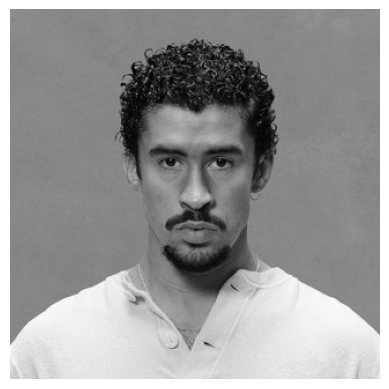

In [23]:
plt.axis('off')
plt.imshow(badbunny, cmap="gray")
plt.show()

## Conversão da imagem

Para que a imagem possa ser processada com o Pytorch, ela precisa ser um tensor de 4 dimensões.

Esse tensor possui a seguinte estrutura [B, C, H, W], em que:
- Batch: denota quantas imagens estão sendo processadas de uma vez (B = 1).
- Channel: denota quantos canais de cor (C = 1 para Cinza, C = 3 para RGB).
- Height: altura da imagem em pixels.
- Width: largura da imagem em pixels.

Use o comando:

img_tensor = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0)

1. torch.from_numpy(img): Converte a matriz do NumPy do Opencv em um tensor do PyTorch
2. float(): converte de uint8 para float
3. unsqueeze(0): adiciona 1 dimensão, i.e., [1, H, W]
4. unsqueeze(0): adiciona outra dimensão, i.e., [1, 1, H, W]

Ao final, temos o tensor desejado.   
Imprima o tipo e sua forma (shape)  
Verifique as dimensões da imagem  

In [24]:
img_tensor = torch.from_numpy(badbunny).float().unsqueeze(0).unsqueeze(0)

In [27]:
print(type(img_tensor))

<class 'torch.Tensor'>


In [28]:
print(img_tensor.shape)

torch.Size([1, 1, 320, 320])


## Filtro Sobel

O filtro Sobel é uma operação utilizada em processamento de imagem, aplicada sobretudo em algoritmos de detecção de contornos. Ele calcula o gradiente da intensidade da imagem em cada ponto, dando a direcção da maior variação de claro para escuro e a quantidade de variação nessa direcção. Assim, obtém-se uma noção de como varia a luminosidade em cada ponto, de forma mais suave ou abrupta. Com isto consegue-se estimar a presença de uma transição claro-escuro e de qual a orientação desta. Como as variações claro-escuro intensas correspondem a fronteiras bem definidas entre objectos, consegue-se fazer a detecção de contornos.

O Filtro Sobel utiliza duas matrizes $3 \times 3$ que são convoluídas com a imagem original $A$ para calcular a magnitude e a direção do gradiente, da seguinte forma:


$$
\mathbf{G_x} = \begin{bmatrix} 
-1 & 0 & +1 \\ 
-2 & 0 & +2 \\ 
-1 & 0 & +1 
\end{bmatrix} * \mathbf{A} 
\quad \text{e} \quad 
\mathbf{G_y} = \begin{bmatrix} 
+1 & +2 & +1 \\ 
0 & 0 & 0 \\ 
-1 & -2 & -1 
\end{bmatrix} * \mathbf{A}
$$

Portanto a magnitude, $\mathbf{G}$, e a direcção, $\mathbf{\Theta}$, do gradiente são dados por:

$$
\begin{aligned}
\mathbf{G} &= \sqrt{\mathbf{G_x}^2 + \mathbf{G_y}^2} \\
\mathbf{\Theta} &= \arctan\left(\frac{\mathbf{G_y}}{\mathbf{G_x}}\right)
\end{aligned}
$$


### Definição dos tensores para as matrizes do Filtro Sobel

Para proceder com a aplicação do Filtro Sobel, crie dois tensores (1,1,3,3) com as matrizes $K_x$ e $K_y$ dadas a seguir:

$$
K_x = \begin{bmatrix} 
-1 & 0 & 1 \\ 
-2 & 0 & 2 \\ 
-1 & 0 & 1 
\end{bmatrix}
$$

$$K_y = \begin{bmatrix} 
+1 & +2 & +1 \\ 
0 & 0 & 0 \\ 
-1 & -2 & -1 
\end{bmatrix}
$$

In [29]:
kx_data = [[-1,  0,  1],
           [-2,  0,  2],
           [-1,  0,  1]]

ky_data = [[ 1,  2,  1],
           [ 0,  0,  0],
           [-1, -2, -1]]

Kx = torch.tensor(kx_data).float().unsqueeze(0).unsqueeze(0)
Ky = torch.tensor(ky_data).float().unsqueeze(0).unsqueeze(0)

print(Kx.shape)
print(Ky.shape)

torch.Size([1, 1, 3, 3])
torch.Size([1, 1, 3, 3])


### Entendendo a Convolução

No contexto de processamento de imagens e visão computacional, a convolução é uma operação matemática em que uma pequena matriz, chaamda filtro ou kernel é "deslizada" sobre a imagem original para extrair características específicas.

- Kernel (Filtro): É uma matriz pequena (como o $G_x$ e $G_y$ no filtro Sobel) que contém pesos matemáticos definidos para detectar padrões
- Operação de convolução: Em cada posição da imagem, o kernel é sobreposto aos pixels da imagem. Multiplica-se cada peso do kernel pelo valor do pixel correspondente e somam-se todos esses resultados.
- Mapa de Características: O resultado dessa soma torna-se um único pixel na nova imagem (o "feature map"). Esse novo valor indica a presença ou a força da característica naquele local exato.

#### Exercício de Convolução Manual

Considere a matriz da imagem $\mathbf{M}$ e o filtro $\mathbf{F}$ a seguir:

$$
\mathbf{M} = \begin{bmatrix} 
10 & 10 & 0 & 0 \\ 
10 & 10 & 0 & 0 \\ 
10 & 10 & 0 & 0 \\ 
10 & 10 & 0 & 0 
\end{bmatrix}
\quad , \quad
\mathbf{F} = \begin{bmatrix} 
-1 & 0 & 1 \\ 
-1 & 0 & 1 \\ 
-1 & 0 & 1 
\end{bmatrix}
$$

**Tarefa:**
Calcule o mapa de características resultante da convolução $(F * M)$. 

**Equação Auxiliar:**
$$y[i, j] = \sum_{m} \sum_{n} \mathbf{M}[i-m, j-n] \cdot \mathbf{F}[m, n]$$

#### Convolução no Pytorch

Utilize  
import torch.nn.functional as F  

e faça   
gx = F.conv2d(img_tensor, kx, padding=1)

Repita o mesmo para obter gy  

In [30]:
gx = F.conv2d(img_tensor, Kx, padding=1)
gy = F.conv2d(img_tensor, Ky, padding=1)

print(gx.shape)
print(gy.shape)

torch.Size([1, 1, 320, 320])
torch.Size([1, 1, 320, 320])


### Magnitude do Gradiente

Calcule a magnitude do gradiente, dada como segue:

$$
\mathbf{G} = \sqrt{\mathbf{G_x}^2 + \mathbf{G_y}^2}
$$ 

Use a função torch.sqrt

In [31]:
G = torch.sqrt(gx**2 + gy**2)

print(G.shape)

torch.Size([1, 1, 320, 320])


### Orientação do gradiente

A orientação do  gradiente é dada por:

$$\mathbf{\Theta} = \arctan\left(\frac{\mathbf{G_y}}{\mathbf{G_x}}\right)$$

Use a função torch.atan2 e converta para graus, multiplicando por $180/\pi$
- Para $\pi$, use a constante do numpy

In [33]:
rad = torch.atan2(gy, gx)
graus = rad * (180/np.pi)

print(graus.shape)
print(graus.max().item())
print(graus.min().item())

torch.Size([1, 1, 320, 320])
180.0
-179.93612670898438


### Visualização do Resultado

- Para visualizar, converta os tensores para array numpy 2D. 
- Normalize a magnitude para o intervalo $[0,255]$
- Utilize o espaço de cores hsv para mostrar a orientação do gradiente
- Exiba os resultados da magnitude e da orientação ao lado da imagem original, de forma comparativa

In [37]:
magnitude_np = G.squeeze().detach().numpy()
orientacao_np = graus.squeeze().detach().numpy()

normalizacao_magnitude = cv.normalize(magnitude_np, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

hsv = np.zeros((normalizacao_magnitude.shape[0], normalizacao_magnitude.shape[1], 3), dtype=np.uint8)

hsv[..., 0] = ((orientacao_np + 180) / 2).astype(np.uint8)
hsv[..., 1] = 255
hsv[..., 2] = normalizacao_magnitude

orientacao_rgb = cv.cvtColor(hsv, cv.COLOR_HSV2RGB)

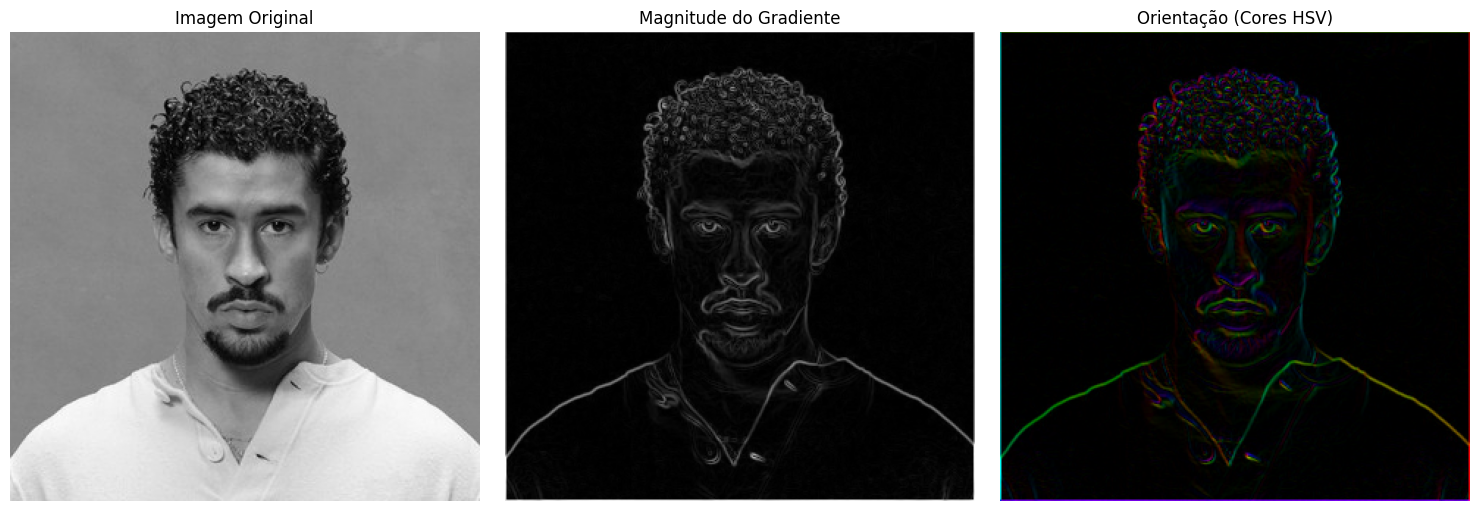

In [38]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(badbunny, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(normalizacao_magnitude, cmap='gray')
plt.title('Magnitude do Gradiente')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(orientacao_rgb)
plt.title('Orientação (Cores HSV)')
plt.axis('off')

plt.tight_layout()
plt.show()

## Construa o vetor de características de Sobel

Observe que temos quatro matrizes além da imagem original (são elas, Gx, Gy, G e Theta). Observe que temos muito mais informação do que inicialmente começamos. Precisamos de um vetor de características global, que captura a essência das características da imagem:

### Flatten

Para obter um vetor (1D), precisamos "planificar" a matriz (2D):  
feat_magnitude = g.cpu().numpy().flatten()

### Dados Estatísticos

O vetor de características será obtido a partir de dados estatísticos da magnitude:
1. Calcule a média da magnitude: Indica a "quantidade" geral de bordas, de tal modo que uma imagem com muitas linhas terá uma média alta.
2. Calcule o desvio padrão da magnitude: Indica o contraste das bordas, isto é, diz se as bordas são todas parecidas ou se há grandes variações de intensidade.
3. Máximo: Identifica a borda mais forte encontrada na imagem.

### Concatenação

Concatene os vetores resultantes (magnitude e dados estatísticos), produzindo uma espécie de resumo das características da imagem avaliadas por Sobel

### Argumente

O vetor de características resultante possui maior dimensão do que a imagem original, além de ter demandado processamento para ser obtido. Como ele pode ser útil em um contexto prático em uma tarefa de Visão Computacional? O esforço realizado vale a pena?